# <font color='steelblue'>Introducción a scikit-learn</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 17/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

In [ ]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install ucimlrepo

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones del curso
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *






# <font color="steelblue">1. Scikit-Learn</font>

**scikit-learn** es una biblioteca de Python de código abierto diseñada para facilitar la implementación de algoritmos de aprendizaje automático. Fue desarrollada inicialmente por **David Cournapeau** como parte de un proyecto de *Google Summer of Code* en **2007**; ese mismo año se incorporó Matthieu Brucher, y a partir de **2010** el INRIA (Instituto Nacional francés de Investigación en Informática y Automática) impulsó el proyecto, publicando la primera versión pública (v0.1 beta) en enero de 2010. La primera versión estable (1.0) llegó en septiembre de 2021, y desde entonces el desarrollo continúa gracias a la contribución de una amplia comunidad de voluntarios y organizaciones ([PyPI](https://pypi.org/project/scikit-learn/)).

Está construida principalmente sobre **NumPy** (operaciones con arrays) y **SciPy** (cómputo científico), y se integra de forma natural con **pandas** (manejo de datos tabulares) y **matplotlib** (visualización, dependencia opcional). Sus partes más exigentes en cómputo están escritas en **Cython/C/C++**, lo que le da un buen rendimiento pese a usarse desde Python. Se distribuye bajo la **licencia BSD de 3 cláusulas**, lo que permite su uso libre, incluso comercial ([PyPI](https://pypi.org/project/scikit-learn/)).

> A fecha de elaboración de estos materiales, la última versión estable es **scikit-learn 1.9.0** (junio de 2026) y requiere **Python ≥ 3.11**. En los enlaces a la documentación conviene usar la ruta `…/stable/…`, que apunta siempre a la versión vigente, en lugar de fijar un número de versión concreto.

## Características principales

1. **Facilidad de uso y API consistente.** Ofrece una interfaz simple y homogénea: prácticamente todos los modelos comparten los mismos métodos —`fit()` para entrenar, `predict()` para predecir y `transform()` para transformar datos—, de modo que aprender a usar un algoritmo facilita el uso de todos los demás. Es accesible y reutilizable en contextos muy diversos.
2. **Amplia gama de algoritmos.** Incluye numerosos algoritmos para clasificación, regresión, *clustering*, reducción de dimensionalidad, selección de modelos y preprocesamiento.
3. **Integración con el ecosistema científico de Python.** Funciona bien con NumPy, SciPy, pandas y matplotlib, lo que permite encadenar la carga de datos, el modelado y la visualización en un mismo flujo de trabajo.
4. **Documentación y comunidad.** Cuenta con una documentación extensa, con ejemplos y guías de usuario, y con una comunidad muy activa.

> **Alcance:** scikit-learn está orientada al aprendizaje automático "clásico" (modelos basados en datos tabulares). No es una librería de *deep learning*; para redes neuronales profundas, visión por computador o procesamiento del lenguaje a gran escala, el ecosistema habitual es **TensorFlow** o **PyTorch**.

Se puede consultar la [documentación oficial](https://scikit-learn.org/stable/index.html) para acceder a todo el contenido.

## Algoritmos principales

1. **Clasificación.** Identificación de la categoría a la que pertenece un objeto. Ejemplos: bosque aleatorio (*random forest*), regresión logística y *k-vecinos más cercanos* (*k-Nearest Neighbors*) ([aprendizaje supervisado](https://scikit-learn.org/stable/supervised_learning.html)).
2. **Regresión.** Predicción de un valor continuo asociado a un objeto. Ejemplos: regresión lineal, bosque aleatorio y regresión *ridge* ([aprendizaje supervisado](https://scikit-learn.org/stable/supervised_learning.html)).
3. **Clustering.** Agrupación automática de objetos similares en conjuntos. Ejemplos: *k-Means* y *DBSCAN* ([aprendizaje no supervisado](https://scikit-learn.org/stable/unsupervised_learning.html)).
4. **Reducción de dimensionalidad.** Disminución del número de variables consideradas, conservando la información relevante. El ejemplo más conocido es el análisis de componentes principales (**PCA**) ([descomposición de señales](https://scikit-learn.org/stable/modules/decomposition.html)). No debe confundirse con la **selección de características**, que elige un subconjunto de las variables originales en lugar de combinarlas ([selección de características](https://scikit-learn.org/stable/modules/feature_selection.html)).

## Herramientas principales

1. **Selección de modelos.** Comparación, validación y elección de hiperparámetros y modelos. Herramientas como la **búsqueda en cuadrícula** (*grid search*) y la **validación cruzada** (*cross-validation*) son esenciales para ajustar y evaluar los modelos de forma fiable ([selección de modelos](https://scikit-learn.org/stable/model_selection.html)).
2. **Preprocesamiento.** Extracción y normalización de características: escalado de variables, codificación de categorías, imputación de valores perdidos o transformación de datos como texto para su uso con los algoritmos ([transformación de datos](https://scikit-learn.org/stable/data_transforms.html)).
3. **Pipelines.** Permiten encadenar preprocesamiento y modelo en un único objeto, de modo que las transformaciones se ajustan solo con los datos de entrenamiento. Esto simplifica el código y, sobre todo, **evita la fuga de información** (*data leakage*) hacia el conjunto de prueba.

## En resumen

scikit-learn es una herramienta potente y versátil para el aprendizaje automático en Python. Su facilidad de uso, su API consistente, la amplia gama de algoritmos y su excelente integración con el resto del ecosistema científico la convierten en una opción ideal tanto para quien empieza como para perfiles expertos. La principal dificultad para quien se inicia es que, en algunos casos, exige cierto nivel de programación para preparar los datos, entrenar los modelos y analizar los resultados.

## Instalación e importación

scikit-learn viene **preinstalada** en distribuciones científicas como **Anaconda** y en entornos como **Google Colab**, por lo que en esos casos no hace falta instalar nada. Un detalle a recordar: aunque el paquete se llama **`scikit-learn`** al instalarlo, **se importa como `sklearn`**:

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


# <font color="steelblue">2. Estudios de caso iniciales</font>

A continuación presentamos y cargamos los bancos de datos que vamos a utilizar en este cuaderno.

**stroke:** Este conjunto de datos se utiliza para predecir si un paciente tiene más o menos probabilidad de sufrir un ictus, en función de su género, edad, enfermedades y hábito de fumar. Cada fila proporciona información sobre un paciente. Las variables predictoras son `gender`, `age`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `avg_glucose_level`, `bmi` y `smoking_status`; la variable respuesta, categórica, es `stroke`, con valores `Yes` y `No`. El fichero incluye además una columna identificadora `id` que debe descartarse antes de modelar. Conviene tener en cuenta dos detalles: la variable `bmi` presenta valores perdidos (201 registros), y el conjunto está muy desequilibrado (solo en torno al 5 % de los pacientes sufren un ictus).

**mushrooms:** La "caza de setas" (también conocida como *shrooming*) está disfrutando de nuevos picos de popularidad. Conocer qué características de las setas implican una muerte segura, y en base a qué resultan más apetecibles, son aspectos de interés. Este conjunto describe las características de una muestra muy extensa de distintos tipos de setas: 23 especies con agallas de las familias *Agaricus* y *Lepiota*, extraídas de *The Audubon Society Field Guide to North American Mushrooms* (1981). Cada seta se identifica mediante la variable respuesta `class`, codificada como `e` (*edible*, comestible) y `p` (*poisonous*, venenosa).

Las variables predictoras son `cap-shape`, `cap-surface`, `cap-color`, `bruises`, `odor`, `gill-attachment`, `gill-spacing`, `gill-size`, `gill-color`, `stalk-shape`, `stalk-root`, `stalk-surface-above-ring`, `stalk-surface-below-ring`, `stalk-color-above-ring`, `stalk-color-below-ring`, `veil-type`, `veil-color`, `ring-number`, `ring-type`, `spore-print-color`, `population` y `habitat`. Todas son categóricas. (Nótese que la variable `odor`, el olor, es una de las más informativas para distinguir setas comestibles de venenosas.)

**alcohol:** Los datos de consumo de alcohol entre adolescentes se obtuvieron de una encuesta a alumnos de matemáticas y de lengua portuguesa de enseñanza secundaria. Además de las variables de consumo, se dispone de mucha información social, de género y de estudios. En este caso no hay variable respuesta (uso no supervisado). El fichero que cargamos, `student-mat.csv`, corresponde **únicamente al curso de matemáticas** (395 alumnos); los datos del curso de lengua portuguesa están en un fichero distinto.

Las variables consideradas son `school`, `sex`, `age`, `address`, `famsize`, `Pstatus`, `Medu`, `Fedu`, `Mjob`, `Fjob`, `reason`, `guardian`, `traveltime`, `studytime`, `failures`, `schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, `health`, `absences`, `G1`, `G2` y `G3`. Aquí `Dalc` y `Walc` recogen el consumo de alcohol entre semana y en fin de semana, y `G1`, `G2`, `G3` son las calificaciones de los tres periodos.

**winequality:** Este banco de datos permite predecir la calidad del vino (`quality`), medida en una escala discreta (de 0 a 10, aunque en la práctica los valores observados van de 3 a 8), para las variantes **tintas** del vino portugués *Vinho Verde*, en función de variables fisicoquímicas.

Las variables predictoras fisicoquímicas son `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates` y `alcohol`.

El código de lectura de los bancos de datos propuestos es:


In [ ]:
import pandas as pd

# CARGA DE LOS BANCOS DE DATOS EN EL CUADERNO

# Stroke Prediction Dataset
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/stroke_ori.csv'
stroke = pd.read_csv(url)

# Mushroom classification
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/mushrooms.csv'
mushrooms = pd.read_csv(url)

# Student Alcohol Consumption (curso de matemáticas)
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/student-mat.csv'
alcohol = pd.read_csv(url)

# Winequality-red
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/winequality-red.csv'
winequality = pd.read_csv(url)

Hacemos a continuación una inspección visual de cada uno de ellos, para verificar que la carga se ha realizado correctamente.

In [ ]:
# Primeros registros de la base de datos stroke
stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,51676,Female,61.0,No,No,Yes,Self-employed,Rural,202.21,NaN,never smoked,Yes
2,31112,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
3,60182,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
4,1665,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes


In [ ]:
# Nombres de las variables de la base de datos mushrooms
mushrooms.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [ ]:
# Dimensión (filas, columnas) de la base de datos alcohol
alcohol.shape

(395, 33)

In [ ]:
# Información general y tipos de variable de la base de datos winequality
winequality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# <font color="steelblue">3. Tablas de datos</font>

El aprendizaje automático crea modelos a partir de datos, que necesariamente han de proporcionarse bien estructurados y preprocesados. Por esa razón, nos detenemos en primer lugar en mostrar cómo organizar los datos para que los módulos de análisis puedan trabajar con ellos eficientemente. En la situación más sencilla, la información para analizar o modelizar se debe estructurar como una **tabla de datos**.

Una tabla de datos es una cuadrícula bidimensional que contiene la información recogida, de modo que las filas (a las que aludiremos como "muestras") representan registros individuales del conjunto de datos y las columnas contienen información relacionada con cada una de las variables observadas. Para ejemplificar lo que es una tabla de datos consideramos el conjunto de datos **Iris**, analizado por Ronald Fisher en 1936, muy habitual como ejemplo en los procedimientos de aprendizaje automático.

Este conjunto de datos intenta predecir la taxonomía de tres tipos de flores Iris en función de las longitudes y anchuras de los pétalos y sépalos. Contiene 150 muestras u observaciones. Al ser un conjunto muy utilizado, viene precargado en muchos módulos de Python, en formato de *DataFrame* de Pandas, y no es necesario descargarlo. En este caso hemos optado por cargarlo a partir de la librería **Seaborn** (que importamos, junto con Pandas, al inicio del cuaderno con `import seaborn as sns` e `import pandas as pd`). A continuación se muestran las primeras líneas:

In [ ]:
# Cargamos los datos
iris = sns.load_dataset('iris')
# Mostramos las primeras líneas
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


En la tabla, cada fila representa una flor observada, de modo que el número total de filas es el número de flores observadas en el experimento. Nos referiremos a las filas como **muestras** y a su número como **`n_muestras`**. Asimismo, cada columna contiene la información cuantitativa o cualitativa recopilada en las variables observadas. Nos referiremos a las columnas como **variables** y a su número como **`n_variables`**. Por último, denotaremos por **`n_respuestas`** al número de variables que actúan como respuestas u objetivos a predecir.

Si no disponemos de ninguna respuesta (`n_respuestas = 0`), como ocurre en el aprendizaje no supervisado, solo hablaremos de una matriz de predictoras, de dimensión `n_muestras × n_variables`. En el aprendizaje supervisado, en cambio, la tabla de datos se suele dividir en dos matrices, predictoras y respuestas:

- **Matriz de predictoras:** por convención se denota por $X$. Tiene dimensión `n_muestras × (n_variables − n_respuestas)` y se almacena habitualmente como una matriz NumPy o, preferiblemente, como un *DataFrame* de Pandas para facilitar su manipulación.
- **Matriz o vector de respuestas:** por convención se denota por $Y$. Tiene dimensión `n_muestras × n_respuestas` y contiene las etiquetas o valores numéricos que queremos aprender a partir de la información de $X$. En la terminología habitual de los modelos de aprendizaje automático, esta matriz se denomina *target*. Lo más frecuente es disponer de una única variable objetivo, de modo que la dimensión de $Y$ será `n_muestras × 1`.

Así, si nuestro objetivo es la clasificación de las flores Iris —identificar su especie a partir de las características fisiológicas—, la matriz de predictoras viene dada por:

In [ ]:
# Variables predictoras
var_car = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
# Matriz de predictoras
X = iris[var_car]
# Mostramos la cabecera y su dimensión
print(X.head())
print("Dimensión:", X.shape)

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
Dimensión: (150, 4)


> Cuando la respuesta es una única columna conocida, una forma cómoda de construir $X$ sin enumerar todas las predictoras es eliminar la columna objetivo: `X = iris.drop(columns='species')`.

La variable objetivo es `species`, que contiene la etiqueta que identifica la especie de cada muestra:

In [ ]:
# Matriz de respuestas u objetivo
Y = iris['species']
# Mostramos la cabecera y su dimensión
print(Y.head())
print("Dimensión:", Y.shape)

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object
Dimensión: (150,)


Conviene observar que $X$ es bidimensional (`(150, 4)`) mientras que $Y$ es unidimensional (`(150,)`): esta es justamente la forma que esperan los modelos de scikit-learn, que reciben una matriz de predictoras 2D y un vector de respuestas 1D.

Podemos obtener una descripción más rápida del conjunto de datos con `.info()`:

In [ ]:
# Descripción del data frame
print(iris.info())
# Respuestas posibles del target
print("\n Valores del target:", iris['species'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

 Valores del target: ['setosa' 'versicolor' 'virginica']


### Otras funciones útiles para la inspección inicial

Además de `.head()` e `.info()`, en una primera exploración resultan muy útiles:

In [ ]:
# Resumen estadístico de las variables numéricas
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


`describe()` ofrece media, desviación, mínimos, máximos y cuartiles de las variables numéricas

In [ ]:
# Frecuencia de cada categoría del target (¿están balanceadas las clases?)
iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


`value_counts()` permite comprobar el reparto de clases del *target* (clave para detectar desequilibrios)

In [ ]:
# Conteo de valores perdidos por variable
iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


`isnull().sum()` revela posibles valores perdidos que habrá que tratar antes de modelar.

## Tipos de variables

Los tipos de variables más comunes en la práctica son:

- `category` u `object` para variables **categóricas**; si las categorías están ordenadas, es posible añadir el orden (lo veremos más abajo);
- `int` para variables numéricas de tipo **entero**;
- `float` para variables numéricas con **decimales**;
- `string` para variables que contienen **cadenas de texto**;
- `boolean` para variables **booleanas** (verdadero/falso);
- `datetime` para variables que contienen **fechas y horas**.

Para identificar y modificar el tipo de las variables de una tabla `datos` (un *DataFrame* de Pandas) usamos las siguientes funciones:

- `datos.dtypes` proporciona el tipo de todas las variables;
- `datos['nombre_var'].astype()` (o `datos.nombre_var.astype()`) modifica el tipo de la variable `nombre_var` según el argumento de `astype()`;
- `datos.select_dtypes(include=[...])` selecciona todas las variables de los tipos especificados en la lista `include`.

Es interesante también conocer el uso de la función `set_index()`. Generalmente, las bases de datos integran una columna con la identificación de los registros (filas). Con `set_index()` indicamos que esa variable ha de reconocerse como identificador, sacándola del conjunto de variables predictoras. Por ejemplo, el conjunto `stroke` incluye una columna `id`:

In [ ]:
# El conjunto stroke incluye una columna identificadora 'id'
stroke.head(3)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,51676,Female,61.0,No,No,Yes,Self-employed,Rural,202.21,NaN,never smoked,Yes
2,31112,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes


In [ ]:
# La fijamos como índice de las filas
stroke = stroke.set_index('id')
stroke.head(3)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
51676,Female,61.0,No,No,Yes,Self-employed,Rural,202.21,NaN,never smoked,Yes
31112,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes


> Tras `set_index('id')`, la columna `id` deja de ser una variable más y pasa a etiquetar las filas, de modo que no se incluirá por error como predictora en los análisis posteriores.

## Ejemplo 1

Consideramos el conjunto de datos `alcohol`, presentado al inicio de este cuaderno.

En primer lugar es siempre conveniente inspeccionar la tabla de datos, por ejemplo mostrando los primeros registros con `.head()`:

In [ ]:
# Cabecera de datos
alcohol.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
# Tipos de variables
alcohol.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


La base de datos contiene exclusivamente variables de tipo `object` (que se corresponden con variables categóricas) y de tipo `int64` (variables numéricas). Para trabajar de forma más eficiente conviene convertir las variables de tipo `object` al tipo `category`.

¿Por qué `category` y no `object`? Porque almacena cada categoría una sola vez y guarda en las filas solo códigos enteros, lo que **ahorra mucha memoria** y acelera operaciones como agrupaciones o conteos. Además, permite definir un **orden** entre categorías (útil para las variables ordinales). El ahorro puede ser muy notable; por ejemplo, la columna `school` pasa de ocupar unos 20 KB como `object` a menos de 1 KB como `category`.

Para convertir, seleccionamos las columnas de tipo `object` con `select_dtypes(include=['object'])` y cambiamos su tipo con `astype("category")`:

In [ ]:
# Nombres de las columnas de tipo object
alcohol.select_dtypes(include=['object']).columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [ ]:
# Seleccionamos los nombres de las columnas de tipo object
cat_names = alcohol.select_dtypes(include=['object']).columns.values
# Las convertimos a tipo category
alcohol[cat_names] = alcohol[cat_names].astype("category")
# Vemos el resultado
alcohol.dtypes

,0
school,category
sex,category
age,int64
address,category
famsize,category
Pstatus,category
Medu,int64
Fedu,int64
Mjob,category
Fjob,category


Por otro lado, hay variables de naturaleza categórica que, al estar **codificadas con números**, se interpretan como `int64`. Son:

- `Medu` (estudios de la madre): 0 = ninguno, 1 = primaria (4.º), 2 = de 5.º a 9.º, 3 = secundaria, 4 = superior;
- `Fedu` (estudios del padre): misma escala 0–4;
- `famrel` (relación familiar): de 1 a 5;
- `freetime` (tiempo libre): de 1 a 5;
- `goout` (salir con amigos): de 1 a 5;
- `Dalc` (consumo de alcohol entre semana): de 1 a 5;
- `Walc` (consumo de alcohol en fin de semana): de 1 a 5;
- `health` (estado de salud): de 1 a 5.

Las convertimos también a categóricas con `astype('category')`:

In [ ]:
# Columnas de tipo int64 que representan categorías
cat_names = ['Medu', 'Fedu', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
# Las convertimos a tipo category
alcohol[cat_names] = alcohol[cat_names].astype("category")
# Vemos el resultado
alcohol.dtypes

,0
school,category
sex,category
age,int64
address,category
famsize,category
Pstatus,category
Medu,category
Fedu,category
Mjob,category
Fjob,category


> Nota: la variable `famsize` ya era de tipo `object`, por lo que quedó convertida a `category` en el paso anterior; no es necesario incluirla aquí.

## Variables categóricas nominales y ordinales

No todas las variables categóricas son iguales. Conviene distinguir:

- **Nominales:** sus categorías no tienen un orden natural (por ejemplo `sex`, `school`, `Mjob` o `reason`).
- **Ordinales:** sus categorías siguen un orden (por ejemplo `Medu` con 0 < 1 < 2 < 3 < 4, las escalas de 1 a 5 como `Walc` o `health`, o `famsize` con `LE3` < `GT3`).

Cuando convertimos con `astype("category")` sin más, Pandas crea categorías **sin orden** (nominales). Para las variables ordinales perdemos así una información valiosa. Para conservarla, definimos un tipo categórico ordenado con `pd.CategoricalDtype(categories=[...], ordered=True)`:

In [ ]:
# Escala de 0 a 4 (estudios de los progenitores)
orden_0_4 = pd.CategoricalDtype(categories=[0, 1, 2, 3, 4], ordered=True)
alcohol[['Medu', 'Fedu']] = alcohol[['Medu', 'Fedu']].apply(lambda c: c.astype(orden_0_4))

# Escala de 1 a 5 (varias variables de hábitos y bienestar)
orden_1_5 = pd.CategoricalDtype(categories=[1, 2, 3, 4, 5], ordered=True)
escala_5 = ['famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
alcohol[escala_5] = alcohol[escala_5].apply(lambda c: c.astype(orden_1_5))

# famsize: LE3 (≤ 3 miembros) < GT3 (> 3 miembros)
orden_fam = pd.CategoricalDtype(categories=['LE3', 'GT3'], ordered=True)
alcohol['famsize'] = alcohol['famsize'].astype(orden_fam)

Una vez definido el orden, las comparaciones tienen sentido y podemos consultar el orden establecido:

In [ ]:
# Comparaciones de orden (esto daría error si la variable fuese categórica SIN orden)
print("Alumnos con consumo alto en fin de semana (Walc >= 4):", (alcohol['Walc'] >= 4).sum())

# Comprobamos el orden definido en famsize
print("Categorías:", alcohol['famsize'].cat.categories.tolist())
print("¿Ordenada?:", alcohol['famsize'].cat.ordered)

Alumnos con consumo alto en fin de semana (Walc >= 4): 79
Categorías: ['LE3', 'GT3']
¿Ordenada?: True


> Esta distinción entre variables nominales y ordinales no es un mero formalismo: será determinante en el apartado de **preprocesamiento**, donde las variables nominales suelen codificarse con *one-hot encoding* (una columna por categoría), mientras que las ordinales pueden codificarse preservando su orden con una *ordinal encoding*, lo que permite a muchos modelos aprovechar esa información.

# <font color="steelblue">4. Proceso de aprendizaje</font>

Una vez que los datos están correctamente estructurados y tipados (apartado anterior), podemos configurar el **proceso de aprendizaje**: la secuencia de pasos que transforma una tabla de datos en un modelo entrenado y evaluado. No se trata de pasos aislados, sino de un flujo en el que el orden y la disciplina importan.

El principio que gobierna todo el proceso es evitar la **fuga de información** (*data leakage*): cualquier cantidad que se *aprenda* de los datos —el valor con el que se imputan los nulos, la media y la desviación con las que se estandariza, las categorías de una codificación o los hiperparámetros de un modelo— debe calcularse **únicamente con el conjunto de entrenamiento** y aplicarse después al de prueba. Si el conjunto de prueba influye en alguna de estas decisiones, la evaluación resultará demasiado optimista y no reflejará el comportamiento real del modelo ante datos nuevos.

La configuración del proceso de aprendizaje involucra cuatro etapas:

1. **Preprocesado de datos:** imputación de valores perdidos, estandarización de variables numéricas y codificación de variables categóricas.
2. **División de muestras:** separación del conjunto en entrenamiento y prueba, y tratamiento de los datos desequilibrados respecto al *target*.
3. **Comparación de modelos:** entrenamiento y comparación de modelos de clasificación o regresión, atendiendo a las métricas habituales.
4. **Entrenamiento del modelo:** ajuste final de un modelo concreto de aprendizaje supervisado.

> En el aprendizaje **no supervisado** (por ejemplo, *clustering*) no hay variable respuesta ni conjunto de prueba en el sentido anterior, de modo que la división y la comparación supervisada de modelos no aplican de la misma forma. Las etapas de preprocesado, sin embargo, siguen siendo necesarias.

A continuación describimos cada etapa y las herramientas que ofrece scikit-learn. En los subapartados siguientes desarrollaremos cada una con ejemplos sobre nuestros conjuntos de datos.

## Preprocesado de datos

Los modelos necesitan datos limpios, numéricos y, en muchos casos, en escalas comparables. El preprocesado prepara las variables para el modelado:

- **Imputación de valores perdidos.** Sustituye los valores ausentes por estimaciones razonables. Herramientas: `SimpleImputer` (media, mediana, moda o un valor constante), `KNNImputer` (a partir de los vecinos más próximos) e `IterativeImputer` (modela cada variable en función de las demás).
- **Estandarización de variables numéricas.** Pone las variables en una escala comparable. Herramientas: `StandardScaler` (media 0 y desviación 1), `MinMaxScaler` (rango [0, 1]) y `RobustScaler` (robusto frente a valores atípicos). Es importante para modelos sensibles a la escala o a las distancias (regresión logística, SVM, *k*-vecinos, redes neuronales); los modelos basados en árboles (*random forest*, *gradient boosting*) no la necesitan.
- **Codificación de variables categóricas.** Convierte las categorías en números. Herramientas: `OneHotEncoder` para variables **nominales** (una columna binaria por categoría) y `OrdinalEncoder` para variables **ordinales** (un entero que respeta el orden). Aquí conecta directamente la distinción nominal/ordinal vista en el apartado anterior.

Para aplicar transformaciones distintas a columnas distintas (por ejemplo, escalar las numéricas y codificar las categóricas) se usa `ColumnTransformer`. Y para encadenar el preprocesado con el modelo en un único objeto que se ajusta solo con el entrenamiento —evitando así la fuga de información de forma automática— se usa `Pipeline`.

## División de muestras

Un aspecto relevante en todos los modelos de aprendizaje automático es el entrenamiento del modelo con una muestra de datos razonablemente grande, denominada **muestra de entrenamiento**, y su posterior evaluación, con otra muestra, denominada **muestra test**, que no se ha utilizado en el entrenamiento y que se utiliza para verificar la calidad del modelo obtenido para predecir datos que no estaban presentes en el entrenamiento. Para ello es necesario dividir el conjunto de datos en dos partes o submatrices de muestras.

- **División entrenamiento/prueba.** La función `train_test_split` separa los datos. Sus argumentos principales son `test_size` (proporción reservada para prueba, p. ej. 0,2), `random_state` (semilla para que la división sea reproducible) y `stratify` (mantiene las proporciones de clase del *target* en ambas particiones, recomendable en clasificación).
- **Datos desequilibrados.** Cuando una clase es mucho más frecuente que otra (como en `stroke`, con ~5 % de casos positivos), un modelo puede "acertar" mucho ignorando la clase minoritaria. Estrategias: estratificar la división o aplicar remuestreo **solo al conjunto de entrenamiento** (sobremuestreo como *SMOTE* —de la librería `imbalanced-learn`—, o submuestreo); y, sobre todo, elegir métricas adecuadas (no basta la *accuracy*).

## Comparación de modelos

Antes de quedarnos con un modelo, conviene comparar varias alternativas de forma justa, usando solo el conjunto de entrenamiento:

- **Validación cruzada.** En lugar de fiarlo todo a una única partición, `cross_val_score` y `cross_validate` reparten el entrenamiento en varios pliegues y promedian el rendimiento. `StratifiedKFold` mantiene las proporciones de clase en cada pliegue.
- **Búsqueda de hiperparámetros.** `GridSearchCV` (búsqueda exhaustiva en una rejilla) y `RandomizedSearchCV` (búsqueda aleatoria) ajustan los hiperparámetros mediante validación cruzada.
- **Métricas habituales.**
  - *Clasificación:* exactitud (*accuracy*), precisión (*precision*), exhaustividad (*recall*), *F1*, área bajo la curva ROC (*ROC-AUC*) y la matriz de confusión. El informe `classification_report` las resume.
  - *Regresión:* error absoluto medio (*MAE*), error cuadrático medio (*MSE*), su raíz (*RMSE*) y el coeficiente de determinación (*R²*).

La idea es comparar los modelos candidatos con validación cruzada sobre el entrenamiento, elegir el mejor y reservar el conjunto de prueba para una única evaluación final.

## Entrenamiento del modelo

Una vez elegidos el modelo y sus hiperparámetros, se realiza el **ajuste final** sobre todo el conjunto de entrenamiento con `fit()`, se generan predicciones sobre el conjunto de prueba con `predict()` (o `predict_proba()` para las probabilidades de clase) y se evalúa con las métricas seleccionadas. Esa evaluación sobre datos no vistos es la estimación honesta de cómo generalizará el modelo.

## Una panorámica en código

Aunque desarrollaremos cada etapa por separado, las cuatro suelen integrarse en un único flujo. El siguiente esqueleto muestra cómo encajan (lo concretaremos en los apartados siguientes):

```python
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 2) División: reservamos el conjunto de prueba ANTES de preprocesar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 1) Preprocesado: transformaciones distintas según el tipo de variable
preprocesado = ColumnTransformer([
    ('num', Pipeline([('imputar', SimpleImputer(strategy='median')),
                      ('escalar', StandardScaler())]), variables_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas),
])

# El Pipeline encadena preprocesado + modelo: el preprocesado se ajusta solo con train
modelo = Pipeline([('prep', preprocesado),
                   ('clf', RandomForestClassifier(random_state=42))])

# 3) Comparación: búsqueda de hiperparámetros con validación cruzada sobre el train
busqueda = GridSearchCV(modelo, param_grid={'clf__n_estimators': [100, 300]}, cv=5)
busqueda.fit(X_train, y_train)

# 4) Entrenamiento final y evaluación honesta sobre el conjunto de prueba
print("Mejor configuración:", busqueda.best_params_)
print("Rendimiento en test:", busqueda.score(X_test, y_test))
```


> La gran ventaja de encapsular el preprocesado dentro del `Pipeline` es que, durante la validación cruzada y la búsqueda de hiperparámetros, las transformaciones se reajustan en cada pliegue usando solo sus datos de entrenamiento. Así se evita la fuga de información de forma automática, sin tener que gestionarla manualmente.

# <font color="steelblue">5. Análisis Exploratorio</font>

Antes de entrenar cualquier modelo conviene **conocer los datos**: cómo se distribuyen las variables, qué problemas presentan (valores atípicos, perdidos, desequilibrio) y, sobre todo, qué predictoras parecen relacionarse con la variable objetivo. Este análisis descriptivo orienta las decisiones posteriores de preprocesado, selección de variables y elección de modelo, y nos da expectativas realistas sobre lo que se puede aprender.

El tipo de análisis y de gráfico adecuado depende de la **naturaleza de las variables** (numéricas u categóricas) y del **tipo de target** (categórico → clasificación; numérico → regresión). Como ejemplo recurrente usaremos el conjunto `stroke`, que combina predictoras numéricas y categóricas con un target categórico (`stroke`: `Yes`/`No`).

In [ ]:
#@title **Cargar datos Stroke**
stroke = pd.read_csv(
    'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/stroke_ori.csv'
).drop(columns='id')

target = 'stroke'
numericas = stroke.select_dtypes(include=np.number).columns.tolist()
categoricas = [c for c in stroke.select_dtypes(include=['object', 'category']).columns
               if c != target]

print("Numéricas :", numericas)
print("Categóricas:", categoricas)

Numéricas : ['age', 'avg_glucose_level', 'bmi']
Categóricas: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## Análisis del target

El primer paso es estudiar la variable objetivo, porque determina el tipo de problema y revela cuestiones clave como el **desequilibrio de clases**. Si el target es **categórico**, analizamos su distribución con frecuencias y proporciones:

 Frecuencias absolutas
stroke
No     4861
Yes     249
Name: count, dtype: int64


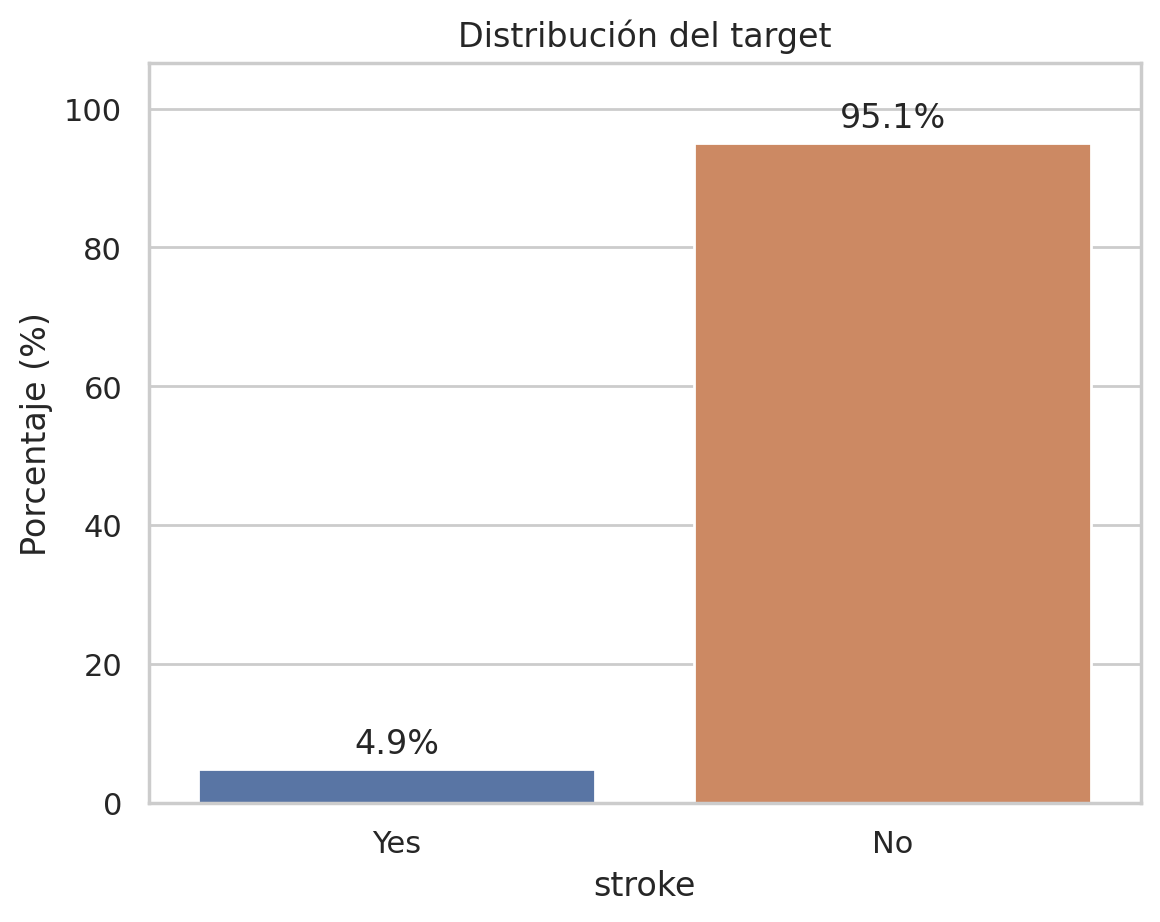

In [ ]:
print(" Frecuencias absolutas")
print(stroke[target].value_counts())

# Gráfico de barras en PORCENTAJE con las etiquetas sobre cada barra
ax = sns.countplot(data=stroke, x=target, stat='percent', hue=target, legend=False)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribución del target')
ax.margins(y=0.12)                       # espacio extra para que quepan las etiquetas
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', padding=3)
plt.show()

En `stroke`, el reparto es **95,1 % `No` y 4,9 % `Yes`**: un desequilibrio fuerte que habrá que tener presente al elegir las métricas (no basta la *accuracy*) y que puede justificar técnicas de equilibrado.

> Si el target fuese **numérico**, en su lugar usaríamos un histograma o una estimación de densidad y un resumen estadístico (`stroke[target].describe()`) para examinar su forma, rango, simetría y posibles valores atípicos.

## Análisis del target frente a cada predictora

Para tener una visión rápida de cómo se relaciona la variable objetivo con **cada una** de las predictoras, recorremos todas ellas y elegimos el gráfico según su tipo: un **diagrama de caja** para las predictoras numéricas (distribución de la variable en cada clase del target) y un **gráfico de barras** para las categóricas (porcentaje de cada clase del target dentro de cada categoría). La función se denomina `descriptivo_target_predictoras`.

In [ ]:
help(descriptivo_target_predictoras)

Help on function descriptivo_target_predictoras in module auto_ML:

descriptivo_target_predictoras(df, target, ncols=3, ancho=5, alto=4)
    Representa el target frente a cada predictora:
      - numéricas  -> diagrama de caja por clase del target
      - categóricas -> barras con el % de cada clase del target dentro de la categoría



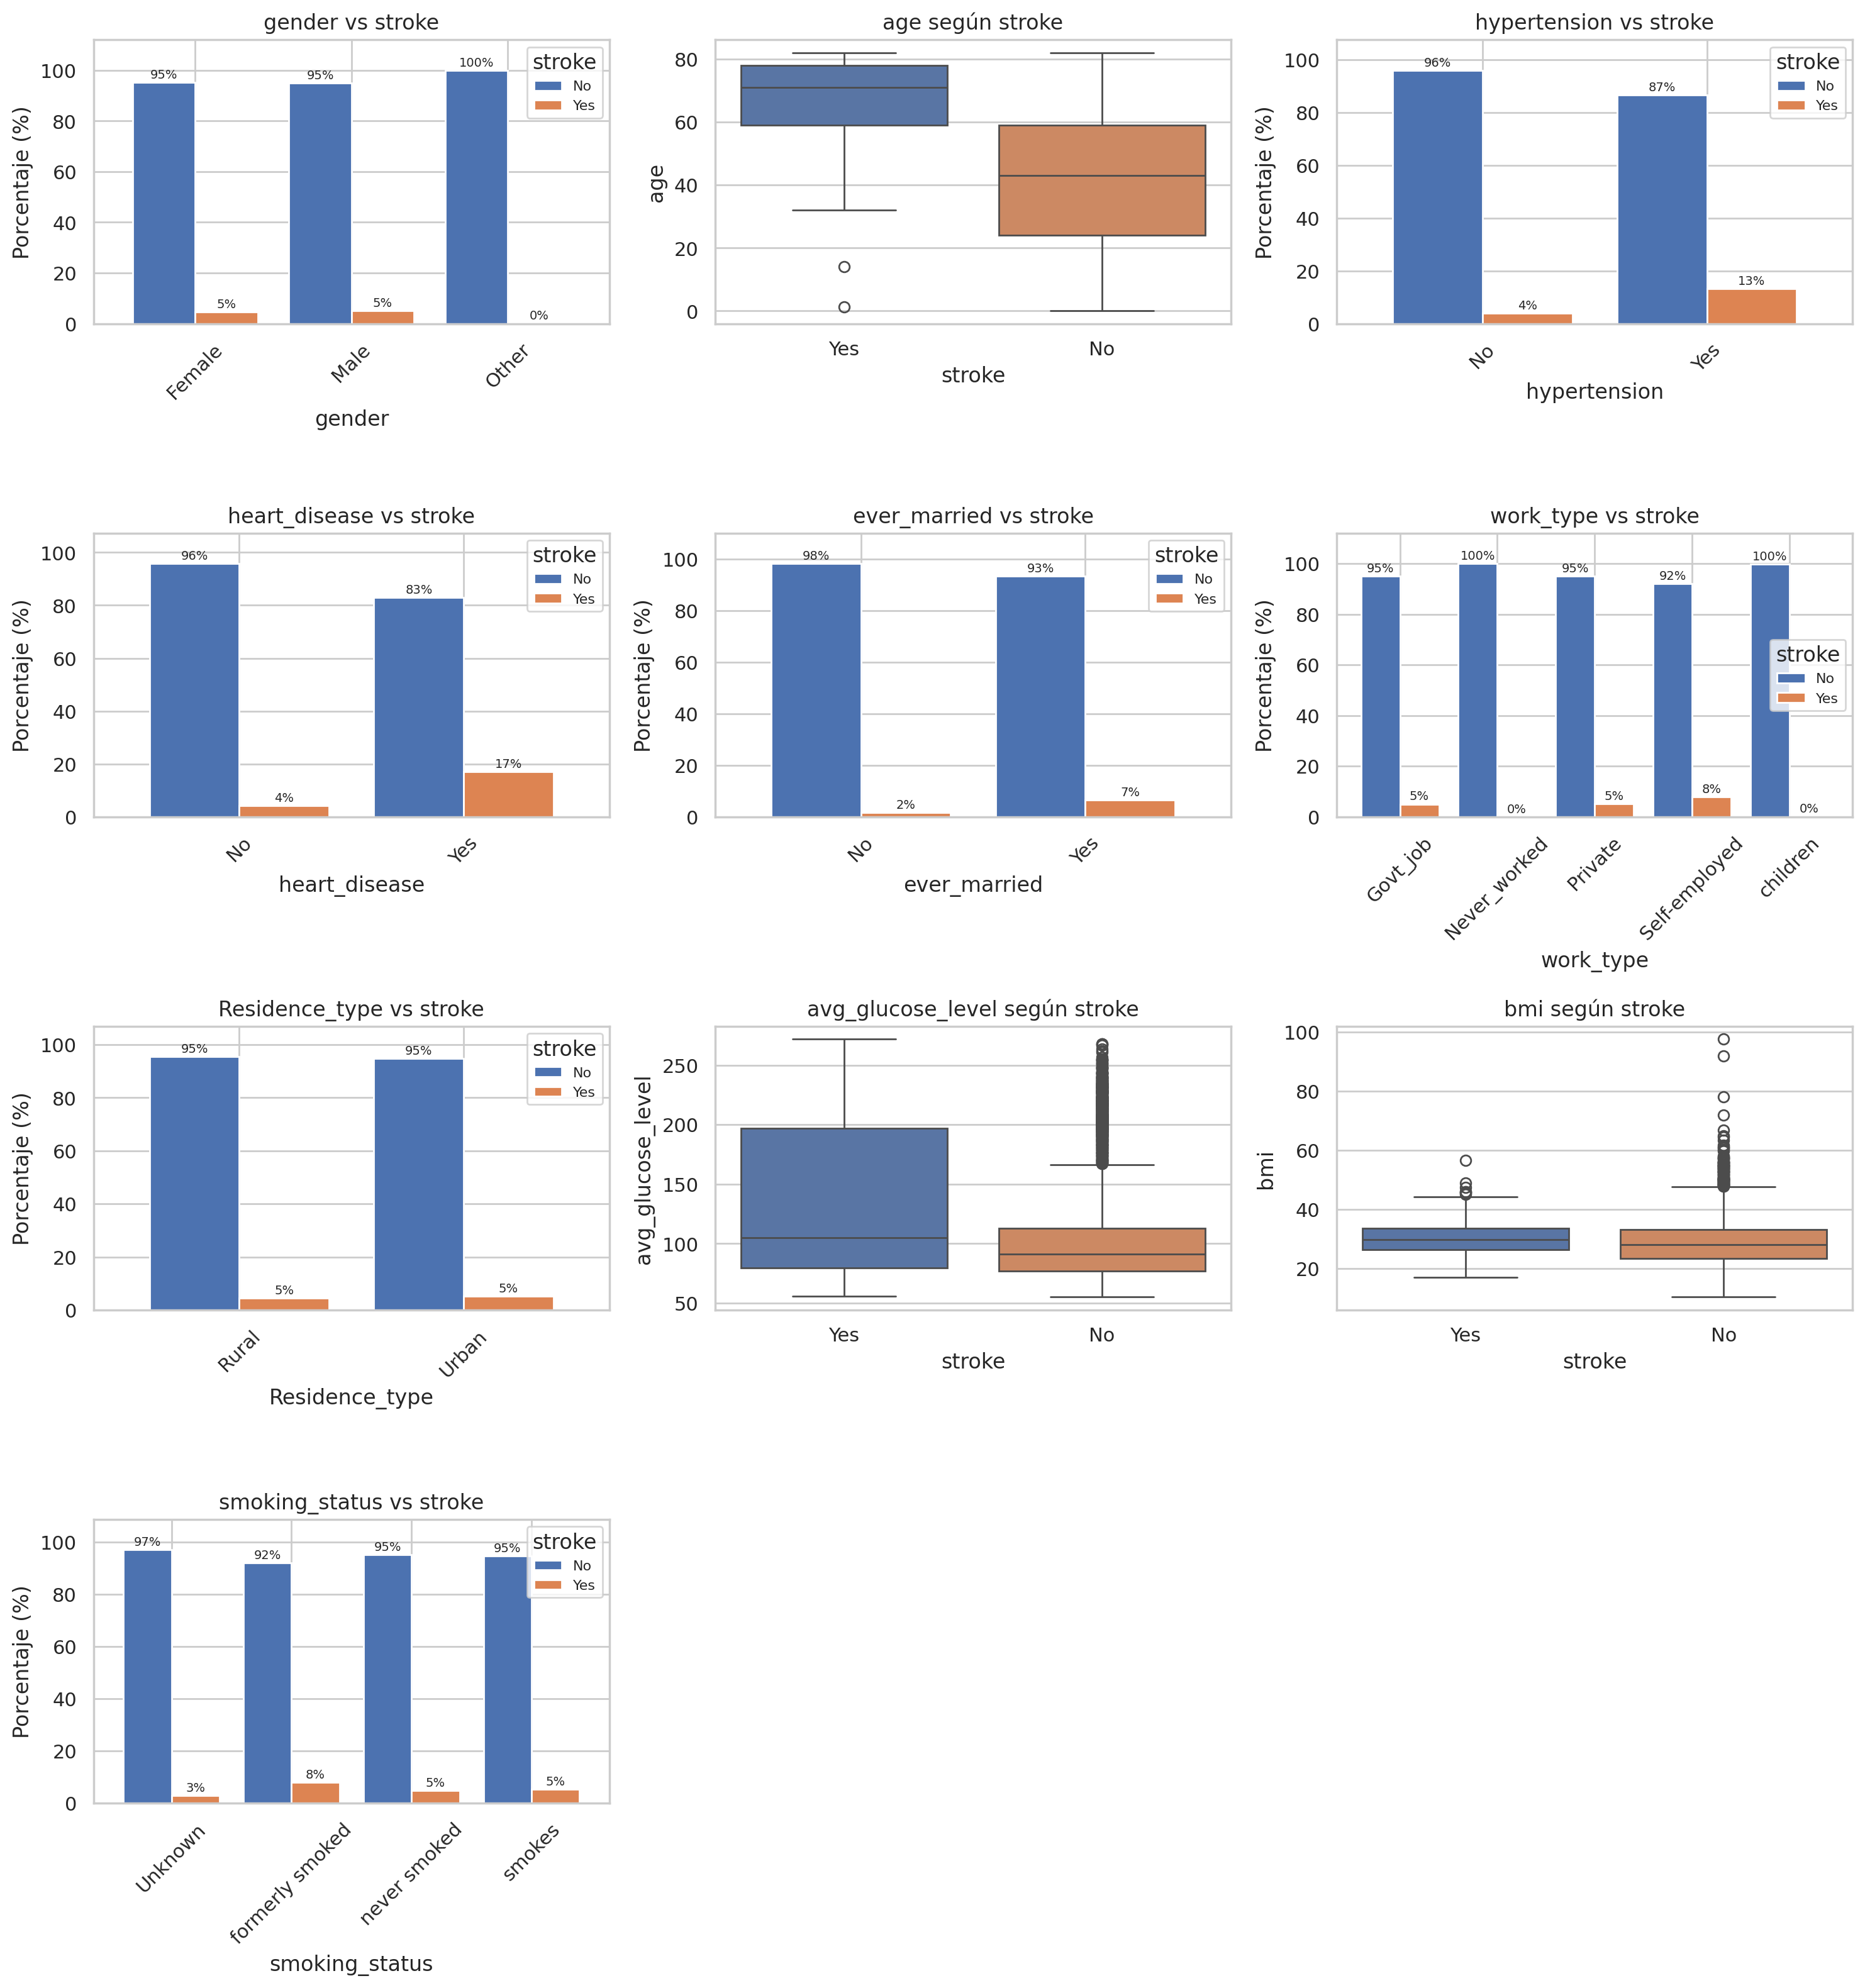

In [ ]:
# Uso
descriptivo_target_predictoras(stroke, target='stroke')

Esta vista permite, de un vistazo, detectar las predictoras que más discriminan el target. En `stroke`, por ejemplo, se aprecia que la **edad** (`age`) es claramente mayor en los pacientes con ictus, y que categorías como `heart_disease = Yes` (≈ 17 % de ictus frente al 4 %) o `hypertension = Yes` (≈ 13 % frente al 4 %) concentran una proporción de eventos mucho mayor, mientras que variables como `gender` o `Residence_type` apenas muestran diferencias entre sus categorías.

> **Nota para targets muy desequilibrados:** al representar ambas clases, la clase minoritaria (aquí `Yes`) aparece como barras pequeñas. Si se quiere resaltar mejor las diferencias entre categorías, una alternativa es graficar únicamente el porcentaje de la clase de interés por categoría. Bastaría con seleccionar esa columna antes de dibujar, por ejemplo: `ct[['Yes']].plot(kind='bar', ax=ax, legend=False)`.



## Correlación entre predictoras numéricas

Estudiar la correlación entre las predictoras numéricas permite detectar **redundancias** (variables que aportan información similar) y posibles problemas de **multicolinealidad**, relevantes sobre todo para modelos lineales.

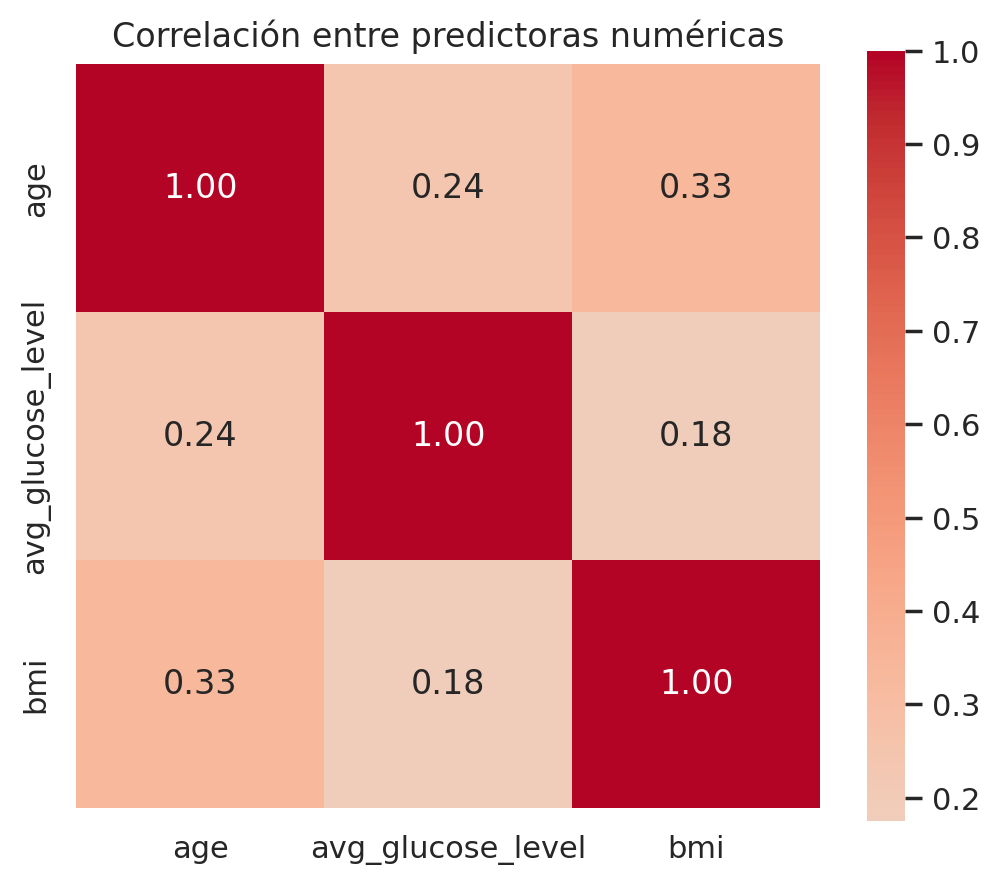

In [ ]:
corr = stroke[numericas].corr(numeric_only=True)   # Pearson por defecto

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlación entre predictoras numéricas')
plt.show()

El coeficiente de **Pearson** mide relación *lineal*; si sospechamos relaciones monótonas no lineales o trabajamos con variables ordinales, conviene usar **Spearman** (`stroke[numericas].corr(method='spearman')`). En `stroke` las correlaciones son moderadas (la mayor es `age`–`bmi`, en torno a 0,33), de modo que no hay redundancia grave entre las numéricas.

## Relación de las predictoras numéricas con las clases del target

Aquí buscamos qué predictoras numéricas **separan** las clases del target. El enfoque es **Diagrama de pares coloreado por la clase**, que muestra simultáneamente distribuciones y relaciones bivariantes separadas por target.

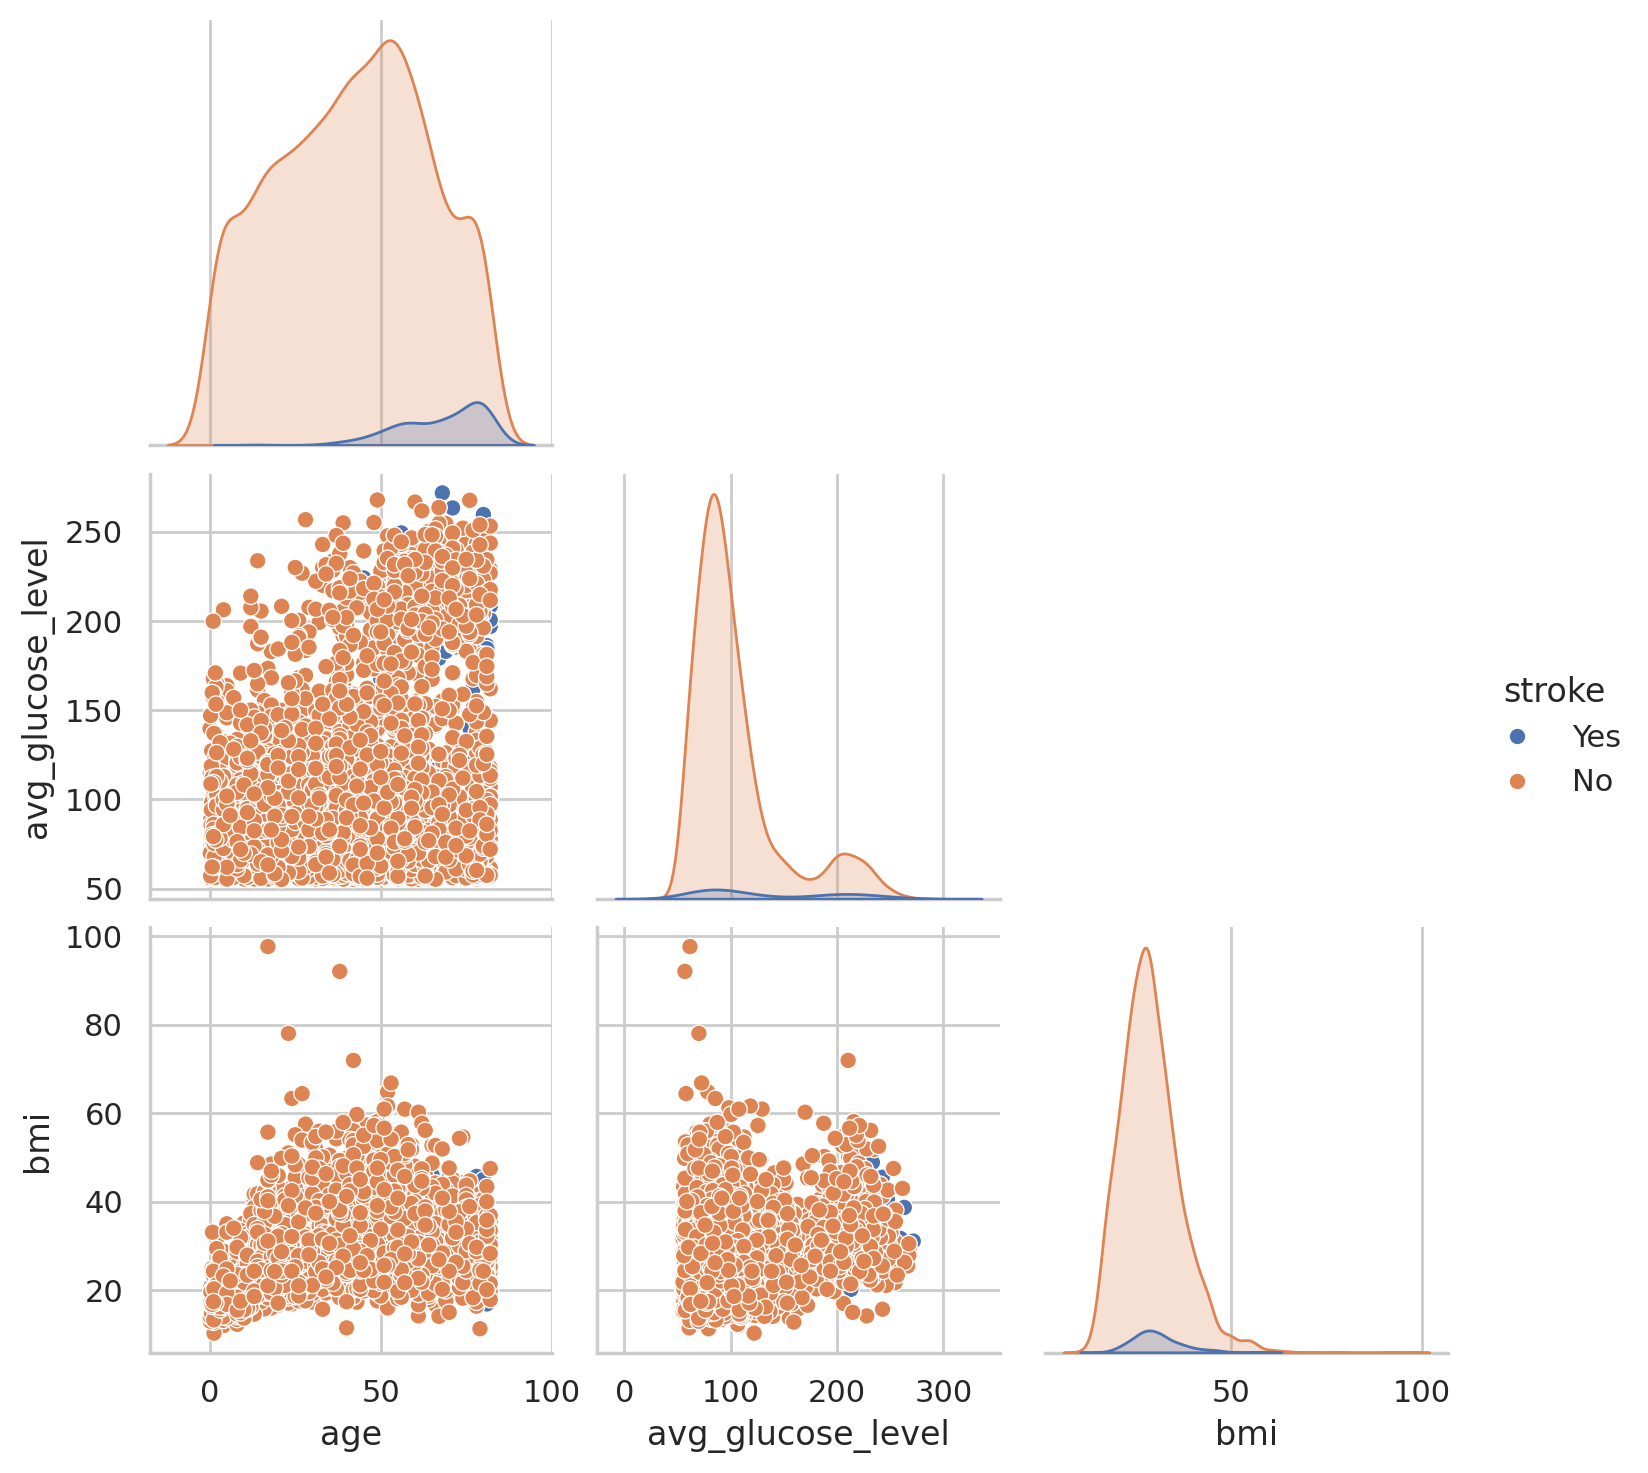

In [ ]:
sns.pairplot(stroke[numericas + [target]].dropna(), hue=target, corner=True)
plt.show()

## Relación entre las predictoras categóricas y el target

Para variables categóricas frente a un target categórico, la correlación de Pearson no aplica. Usamos:

**a) Tablas de contingencia** con proporciones por fila (qué porcentaje de cada categoría sufre el evento):

In [ ]:
print(pd.crosstab(stroke['smoking_status'], stroke[target], normalize='index').round(3))

stroke              No    Yes
smoking_status               
Unknown          0.970  0.030
formerly smoked  0.921  0.079
never smoked     0.952  0.048
smokes           0.947  0.053


**b) Gráficos de barras** (apiladas o agrupadas) para visualizar esas proporciones:

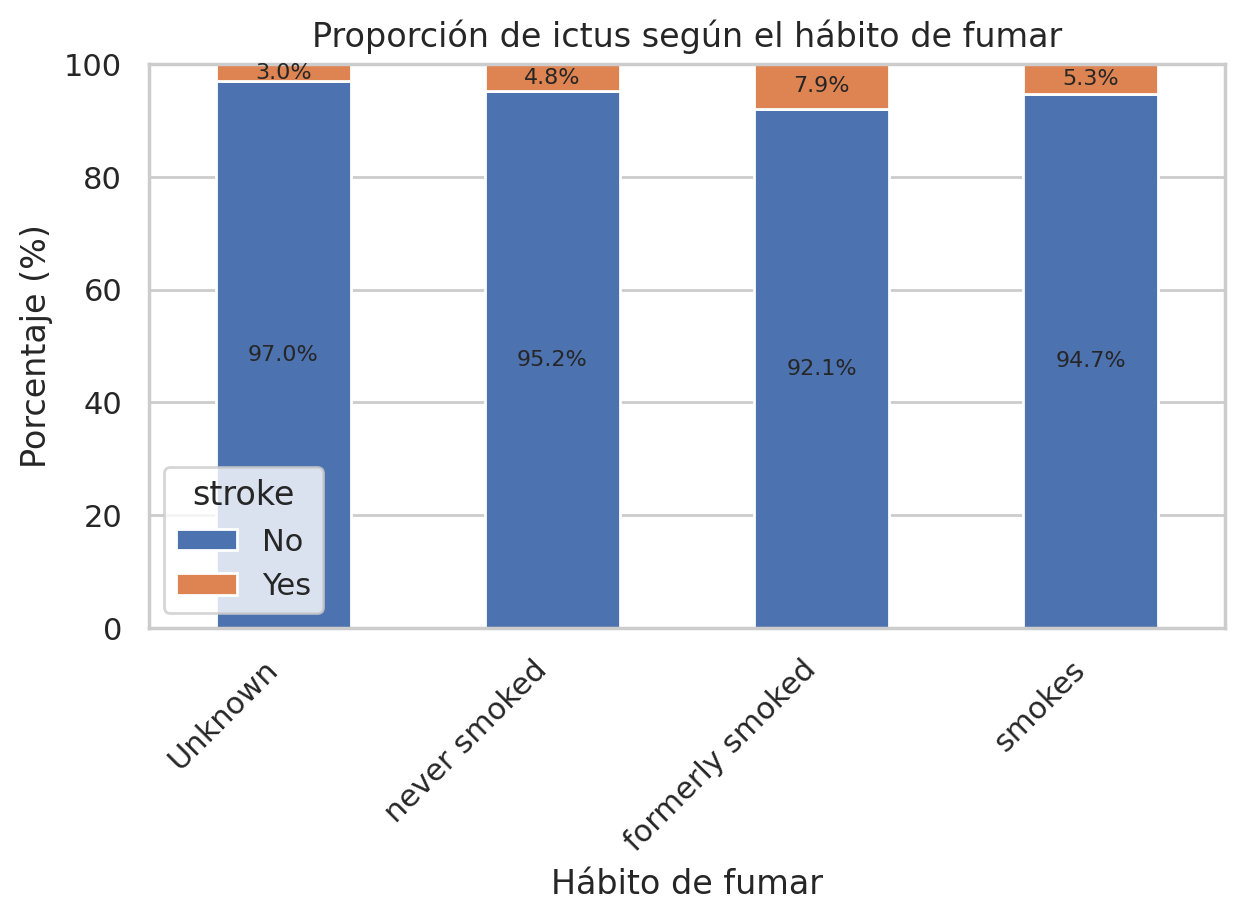

In [ ]:
# Orden de presentación de las categorías en el eje X
orden = ["Unknown", "never smoked", "formerly smoked", "smokes"]

# Proporciones -> porcentajes (x100) y reordenación de las categorías
ct = (pd.crosstab(stroke['smoking_status'], stroke[target], normalize='index')
        .mul(100)
        .reindex(orden))

ax = ct.plot(kind='bar', stacked=True)
ax.set_title('Proporción de ictus según el hábito de fumar')
ax.set_ylabel('Porcentaje (%)')
ax.set_xlabel('Hábito de fumar')
ax.set_ylim(0, 100)                       # eje Y de 0 a 100
ax.legend(title=target)
plt.xticks(rotation=45, ha='right')

# Porcentaje sobre cada segmento de la barra
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

**c) Medidas de asociación.** El **test chi-cuadrado** indica si la asociación es estadísticamente significativa (p-valor), y la **V de Cramér** cuantifica su *fuerza* en una escala de 0 (sin asociación) a 1 (asociación total):

In [ ]:
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.values.sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

for c in categoricas:
    tabla = pd.crosstab(stroke[c], stroke[target])
    p = chi2_contingency(tabla)[1]
    print(f"{c:16s} V de Cramér = {cramers_v(stroke[c], stroke[target]):.3f}   p-valor = {p:.2e}")

gender           V de Cramér = 0.010   p-valor = 7.90e-01
hypertension     V de Cramér = 0.126   p-valor = 1.66e-19
heart_disease    V de Cramér = 0.133   p-valor = 2.09e-21
ever_married     V de Cramér = 0.107   p-valor = 1.64e-14
work_type        V de Cramér = 0.098   p-valor = 5.40e-10
Residence_type   V de Cramér = 0.015   p-valor = 2.98e-01
smoking_status   V de Cramér = 0.076   p-valor = 2.09e-06


Resultados en `stroke`: las categóricas más asociadas al ictus son `heart_disease` (V ≈ 0,13), `hypertension` (≈ 0,13) y `ever_married` (≈ 0,11), todas con p-valores muy pequeños. En cambio, `gender` (V ≈ 0,01, p ≈ 0,79) y `Residence_type` (V ≈ 0,02, p ≈ 0,30) **no muestran asociación** con el target, lo que sugiere que aportan poco a la predicción.

## Representación conjunta de múltiples predictoras y el target

El reto final es visualizar **muchas variables, de distintos tipos, junto al target** en una sola imagen. Algunas soluciones:

**a) Diagrama de pares con color por clase** (`pairplot` con `hue`), ya visto en el paso 3, que combina las predictoras numéricas dos a dos diferenciando el target.

**b) Mapa de calor de correlaciones** para una visión global de las relaciones entre numéricas (paso 2).

**c) Combinación de predictoras numéricas con target** (`radviz` y `radar`).

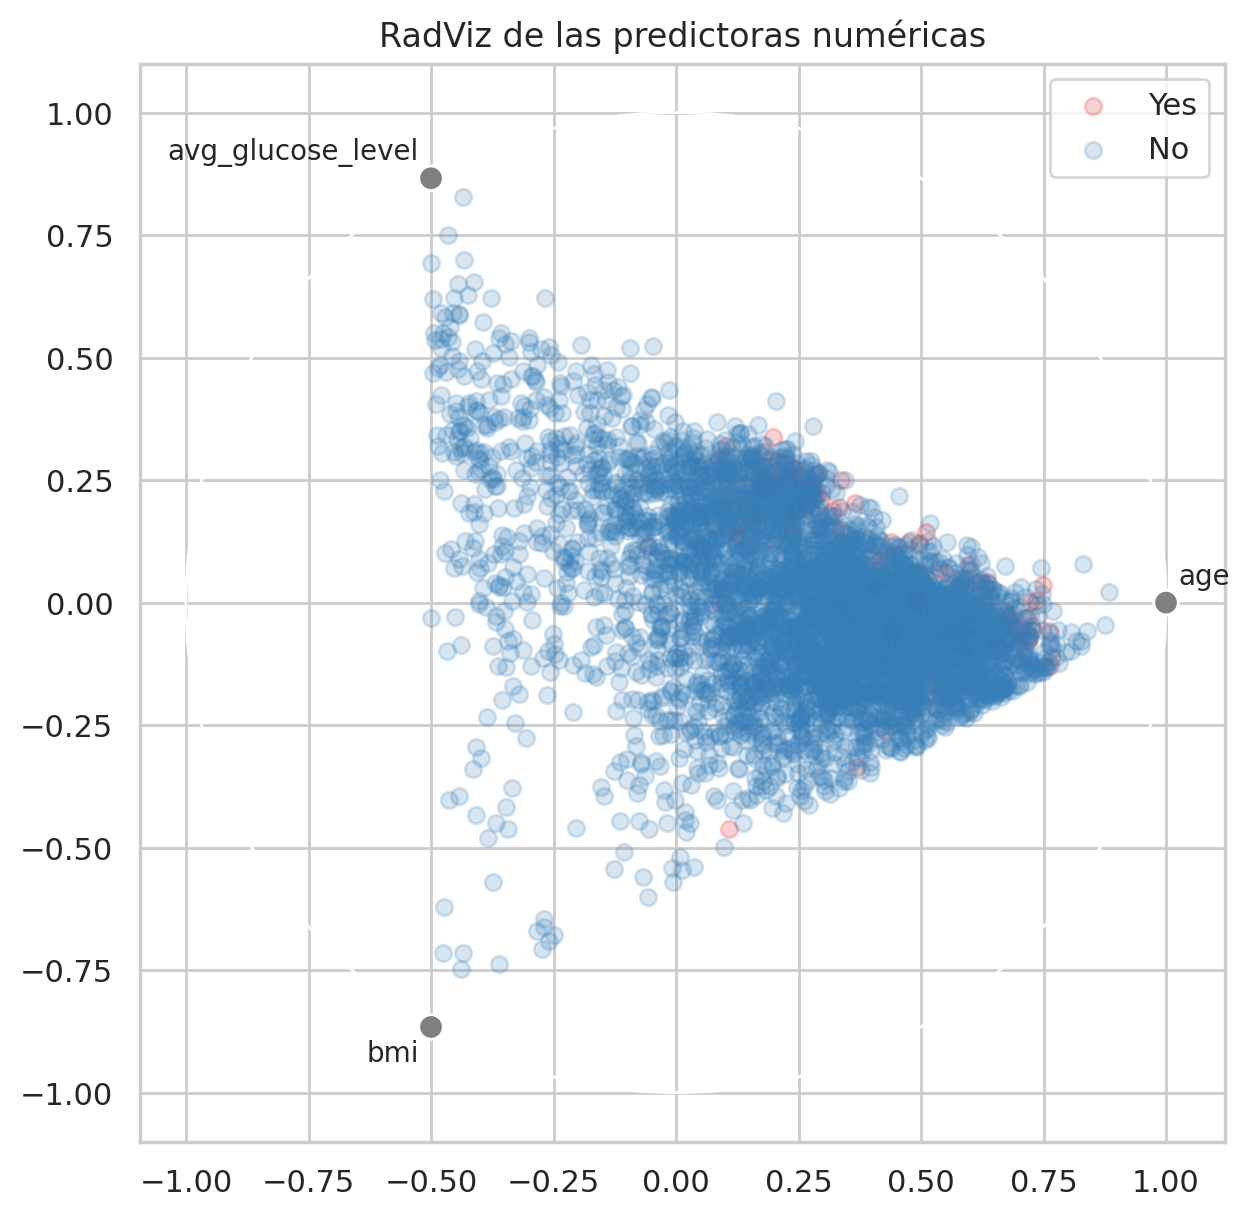

In [ ]:
# Radviz
from pandas.plotting import radviz

# Predictoras numéricas + target, sin nulos
datos = stroke[numericas + [target]].dropna()

plt.figure(figsize=(7, 7))
radviz(datos, class_column=target,
       color=sns.color_palette('Set1', datos[target].nunique()),
       alpha=0.2)                              # alpha bajo por el solapamiento
plt.title('RadViz de las predictoras numéricas')
plt.show()

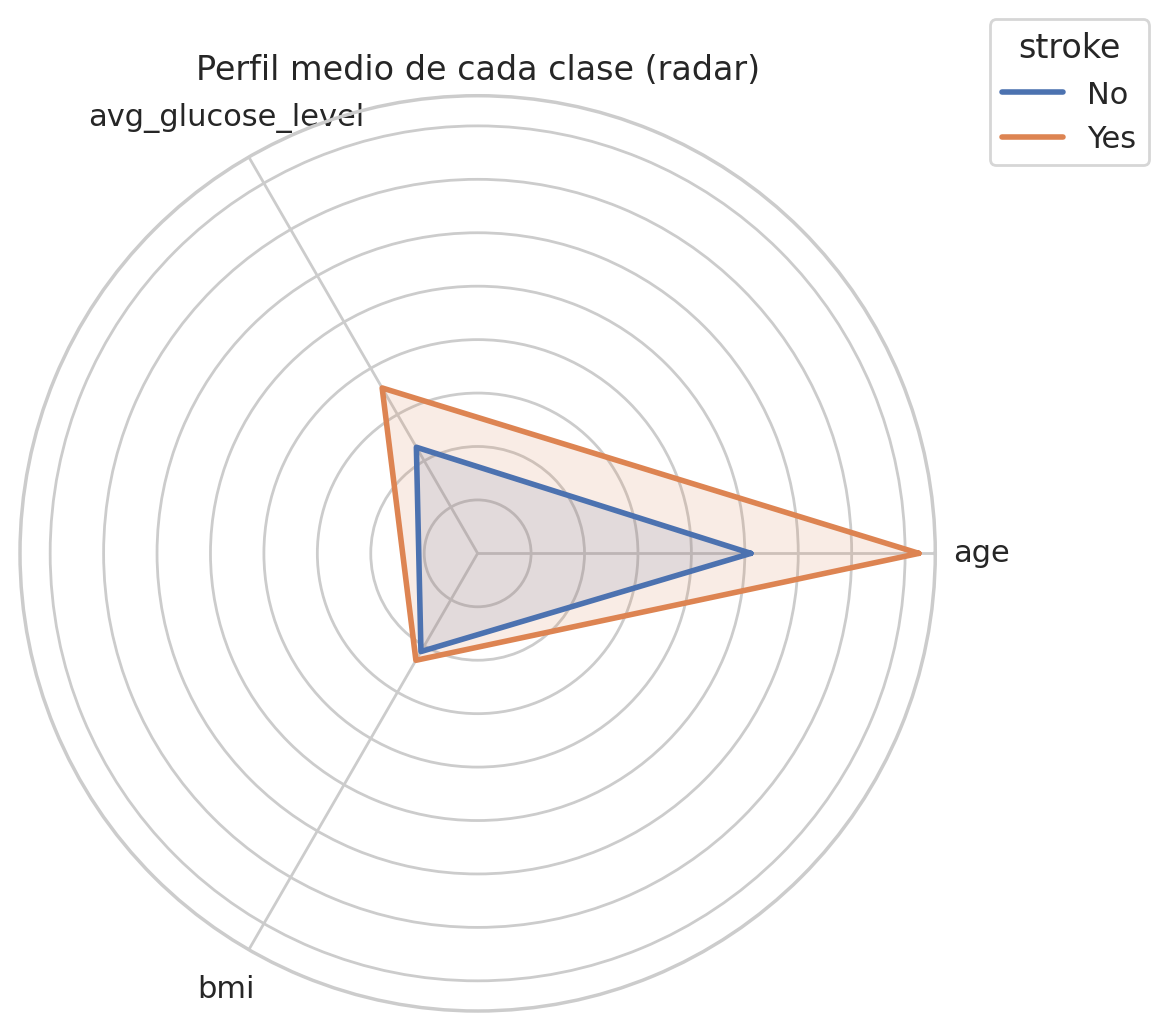

In [ ]:
# Radar
# 1) Perfil de cada clase: media de cada predictora numérica por clase del target
perfil = stroke.groupby(target, observed=True)[numericas].mean()
# 2) Normalizamos cada predictora al rango [0, 1] (escalas muy distintas)
mn, mx = stroke[numericas].min(), stroke[numericas].max()
perfil_norm = (perfil - mn) / (mx - mn)
# 3) Un radio (ángulo) por predictora; repetimos el primero para cerrar el polígono
N = len(numericas)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

# 4) Dibujo en ejes polares: un polígono por clase
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for clase, fila in perfil_norm.iterrows():
    valores = fila.tolist() + [fila.tolist()[0]]   # cerrar el polígono
    ax.plot(angulos, valores, linewidth=2, label=str(clase))
    ax.fill(angulos, valores, alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(numericas)
ax.set_yticklabels([])                              # ocultar la escala radial (es relativa)
ax.set_title('Perfil medio de cada clase (radar)')
ax.legend(title=target, loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

Para finalizar realizamos un gráfico conjunto de diferentes predictoras y el target de interés.

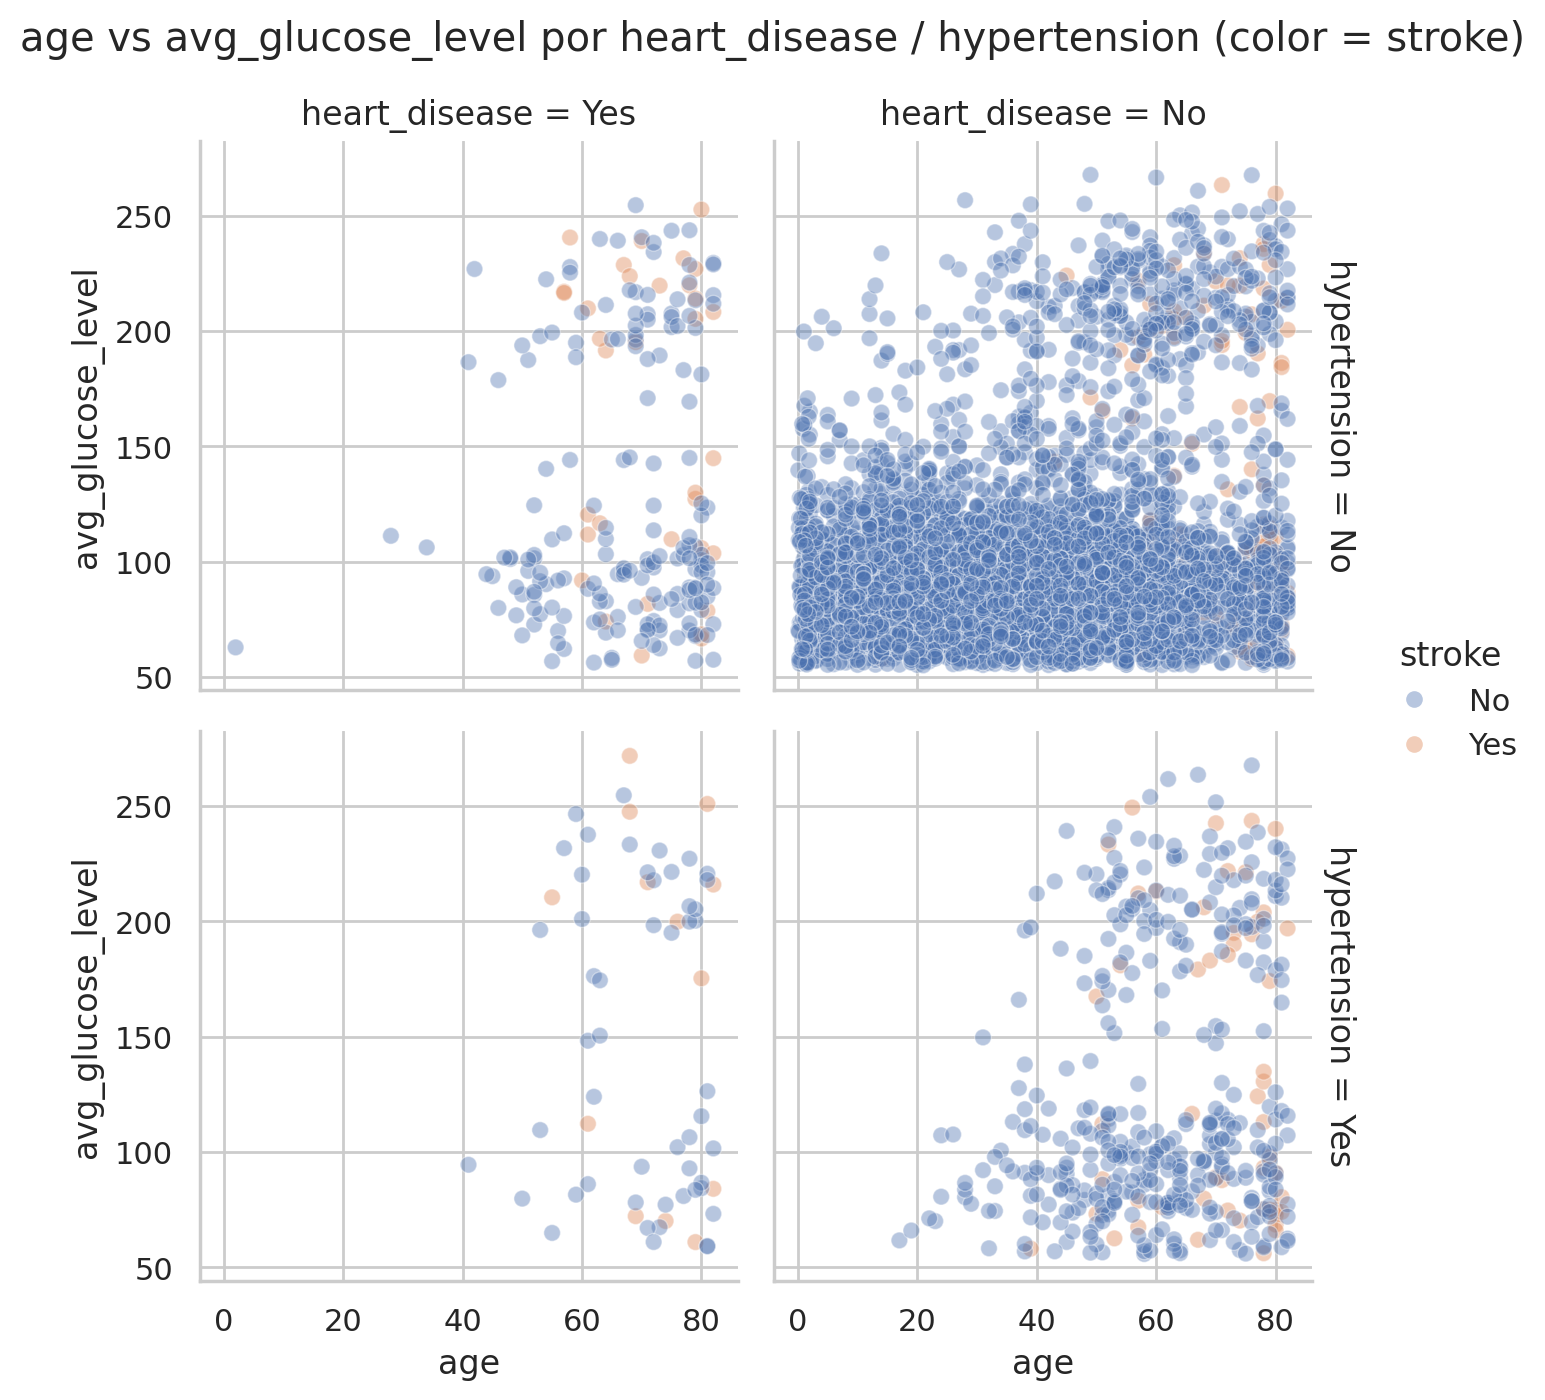

In [ ]:
# Quitamos nulos en las numéricas que vamos a representar
datos = stroke.dropna(subset=['age', 'avg_glucose_level'])

g = sns.relplot(
    data=datos,
    x='age', y='avg_glucose_level',     # las dos predictoras numéricas
    hue=target, hue_order=['No', 'Yes'],# color por la clase del target
    col='heart_disease',                # una categórica en columnas
    row='hypertension',                 # la otra categórica en filas
    alpha=0.4, height=3.4,
    facet_kws={'margin_titles': True},
)
g.set_titles(col_template="heart_disease = {col_name}",
             row_template="hypertension = {row_name}")
g.figure.suptitle('age vs avg_glucose_level por heart_disease / hypertension '
                  '(color = stroke)', y=1.03)
plt.show()

# <font color="steelblue">6. Referencias y enlaces de interés</font>

Los recursos utilizados para elaborar este módulo de aprendizaje, y que puedes utilizar para ampliar información sobre *Machine Learning* con *Scikit-Learn*, han sido:


* Scikit-learn (n.d.). An introduction to machine learning with scikit-learn. Retrieved January 10, 2024, from https://scikit-learn.org/stable/tutorial/basic/tutorial.html.


* Ander Fernández (2021). Tutorial Sklearn Python. Retrieved January 10, 2024, from https://anderfernandez.com/blog/tutorial-sklearn-machine-learning-python/.


* Aurélien Géron (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and Tensorflow: Concepts, Tools, and Techniques to Build Intelligent Systems. O’Reilly Media.

* Peters Morgan (2018). Data Analysis From Scratch With Python: Beginner Guide using Python, Pandas, NumPy, Scikit-Learn, IPython, TensorFlow and Matplotlib. AI Sciences LLC.

* Sebastian Raschka, Vahid Mirjalili (2017). Python Machine Learning: Machine Learning and Deep Learning with Python, scikit-learn, and TensorFlow. Packt Publishing.

* Julian Avila (2017). Scikit-Learn Cookbook: Over 80 Recipes for Machine Learning in Python With Scikit-Learn. Packt Publishing.





